In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'<<{_str}>>:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [2]:
import torch
import torchvision
import matplotlib.pyplot as plt

torchvision.__version__
# 0.18.0+cu121 2408
# 0.20.1+cu121 2411

'0.23.0+cu126'

# Image Datasets

https://pytorch.org/vision/stable/datasets.html

In [3]:
from torchvision.datasets import MNIST, FashionMNIST, CIFAR10, CIFAR100
from torch.utils.data import DataLoader
from torchvision.transforms import v2  ## transforms v2.0 사용

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True) ] )

epochs=3
batch_size=1024

download_root = './MNIST' # 60000, 10000
train_dataset = MNIST(download_root, transform=transform, train=True, download=True)
test_dataset = MNIST(download_root, transform=transform, train=False, download=True)
trainDataLoader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valDataLoader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

download_root = './F-MNIST' # 60000, 10000
fashion_train = FashionMNIST(download_root, transform=transform, train=True, download=True)
fashion_test = FashionMNIST(download_root, transform=transform, train=False, download=True)
fTrainDataLoader = DataLoader(fashion_train, batch_size=batch_size, shuffle=True)
fValDataLoader = DataLoader(fashion_test, batch_size=batch_size, shuffle=False)

download_root = './CIFAR10' # 50000,10000
cifar10_train = CIFAR10(download_root, transform=transform, train=True, download=True)
cifar10_test = CIFAR10(download_root, transform=transform, train=False, download=True)
c10TrainDataLoader = DataLoader(cifar10_train, batch_size=batch_size, shuffle=True)
c10ValDataLoader = DataLoader(cifar10_test, batch_size=batch_size, shuffle=False)

download_root = './CIFAR100' # 50000,10000
cifar100_train = CIFAR100(download_root, transform=transform, train=True, download=True)
cifar100_test = CIFAR100(download_root, transform=transform, train=False, download=True)
c100TrainDataLoader = DataLoader(cifar100_train, batch_size=batch_size, shuffle=True)
c100ValDataLoader = DataLoader(cifar100_test, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.61MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 124kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]
100%|██████████| 26.4M/26.4M [00:03<00:00, 8.42MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 141kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.8MB/s]
100%|██████████| 170M/170M [00:19<00:00, 8.56MB/s]
100%|██████████| 169M/169M [00:13<00:00, 12.1MB/s]


In [4]:
## target lable의 image 확인하기
def img_plot(data, lable, target):
    plt.figure(figsize=(12, 3))
    idx = 0
    data_ = data.permute(0, 2, 3, 1) #(c,h,w)->(h,w,c)
    for i in range(36):
        while lable[idx] != target :
            idx += 1
            if idx >=1024 : idx=0
        plt.subplot(3, 12, i+1)
        if data_.shape[-1] == 1:
            data_ = data_[..., 0]
        plt.imshow(data_[idx])
        plt.axis("off")
        idx += 1
    plt.show()

- 동일 class 이미지들의 다양성 확인하기

In [5]:
p(trainDataLoader)

<<>>:
Type: <class 'torch.utils.data.dataloader.DataLoader'>
Values: <torch.utils.data.dataloader.DataLoader object at 0x7c259f03e8a0>


[] Shapetorch.Size([1024, 1, 28, 28]), <class 'torch.Tensor'>


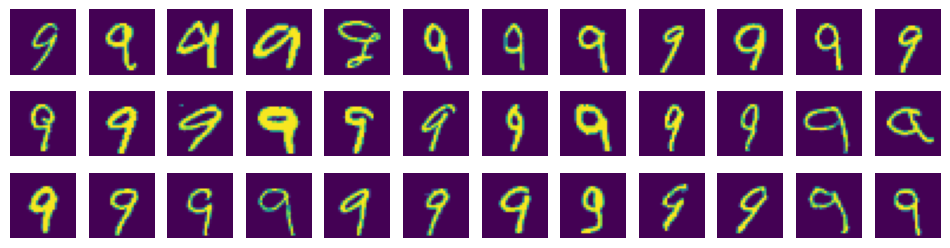

In [8]:
x_train, y_train = next(iter(trainDataLoader))
pst(x_train)
img_plot(x_train, y_train, 9)

**Fashion MNIST class name**   
    0: T-shirt/top, 1: Trouser, 2: Pullover, 3: Dress, 4: Coat   
    5: Sandal, 6: Shirt, 7: Sneaker, 8: Bag, 9: Ankle boot   

[] Shapetorch.Size([1024, 1, 28, 28]), <class 'torch.Tensor'>


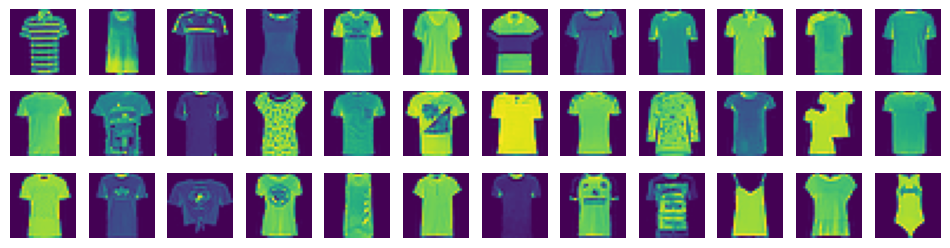

In [9]:
x_train, y_train = next(iter(fTrainDataLoader))
pst(x_train)
img_plot(x_train, y_train, 0)

**0: T-shirt/top**

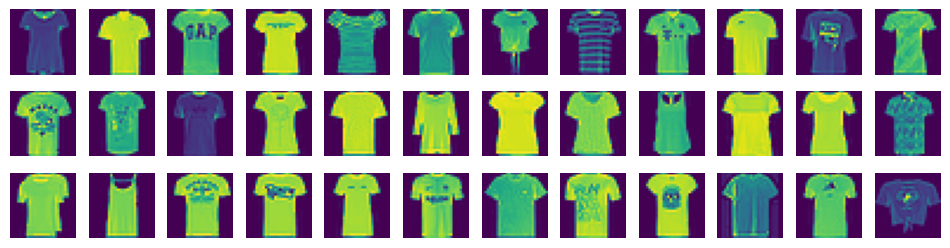

**Shirt**

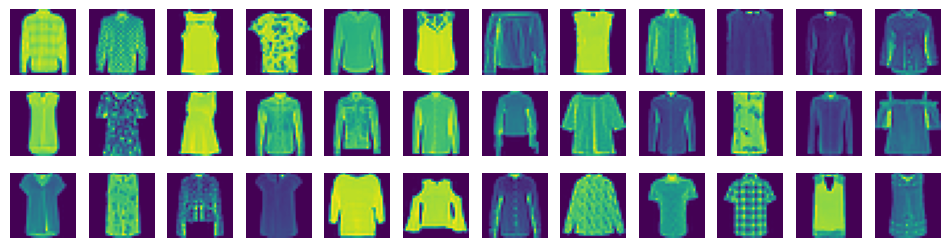

**CIFAR10 class name**   
0: airplane, 1: automobile, 2: bird, 3: cat  
4: deer, 5: dog, 6: frog, 7: horse, 8: ship, 9: truck

[] Shapetorch.Size([1024, 3, 32, 32]), <class 'torch.Tensor'>


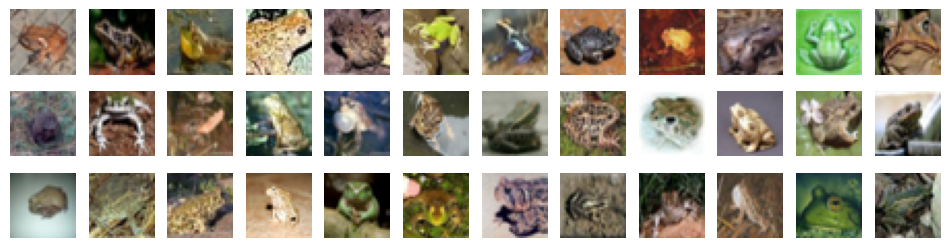

In [16]:
x_train, y_train = next(iter(c10TrainDataLoader))
pst(x_train)
img_plot(x_train, y_train, 6)

**CIFAR100 class name**   
https://huggingface.co/datasets/cifar100

[] Shapetorch.Size([1024, 3, 32, 32]), <class 'torch.Tensor'>


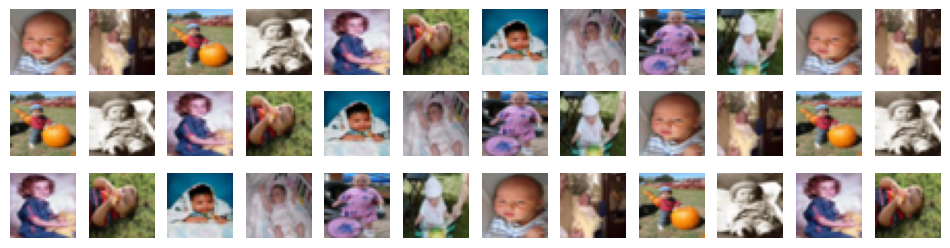

In [17]:
x_train, y_train = next(iter(c100TrainDataLoader)) # bs:1024 / class:100
pst(x_train)
img_plot(x_train, y_train, 2)

In [ ]:
(y_train[:]==1).sum() ## 1024중에 10개정도

tensor(14)